# Data Loading and Inspection

Run the code cells in this first section to load the Online Retail dataset and inspect it. Note: This version of the retail dataset has been preprocessed to remove erroneous transactions and to filter out transactions outside of the United Kingdom. The dataset is stored in a "pickle" format which is specific to Python. A description of each column in the dataset can be found below:

- InvoiceNo - A 6-digit integer uniquely assigned to each transaction
- StockCode - A 5-digit integer uniquely assigned to each distinct product
- Description - Product name

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress excessive warning messages
import warnings
warnings.filterwarnings("ignore")

# Import dataframe from pickle file
df = pd.read_pickle("UK.pkl")

# Checkout out first few rows
df.head(10)

,InvoiceNo,StockCode,Description
1,536365,71053,WHITE METAL LANTERN
5,536365,22752,SET 7 BABUSHKA NESTING BOXES
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER
7,536366,22633,HAND WARMER UNION JACK
8,536366,22632,HAND WARMER RED POLKA DOT
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL
13,536367,22310,IVORY KNITTED MUG COSY


# Transaction Encoding

As you can see, each row in this dataset corresponds to an "InvoiceNo" and "Description" combination. A single transaction is identified by its "InvoiceNo", but there may be multiple rows in the dataframe with the same "InvoiceNo" if more than one item was purchased in the same transaction. The apriori algorithm expects transactions to be represented in a "one-hot" encoded dataframe. This will be performed in two steps, the first being to group items by "InvoiceNo" so that each transaction consists of a list of items purchased, then a transaction encoder is applied to generate the "one-hot" encoded dataframe.

1. Complete the code below to groupby "InvoiceNo" and apply a lambda function to store all items in each group in a list. Then view the results to see that each "InvoiceNo" appears on a single row in a pandas series with the items purchased stored in lists.

In [2]:
# Group sales by "InvoiceNo" and store all items from "Description"
# in a list
df_invoice = df.groupby(["InvoiceNo"]).apply(lambda r: list(r["Description"]))

# Check out the first few rows
df_invoice.head(10)

InvoiceNo
536365    [WHITE METAL LANTERN, SET 7 BABUSHKA NESTING B...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
536371                     [PAPER CHAIN KIT 50'S CHRISTMAS]
536372    [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
536373    [WHITE METAL LANTERN, EDWARDIAN PARASOL RED, R...
536374                         [VICTORIAN SEWING BOX LARGE]
536375    [WHITE METAL LANTERN, EDWARDIAN PARASOL RED, R...
dtype: object

The data is in a format that is suitable for transaction encoding now. The TransactionEncoder class from mlxtend can perform this task using the "fit_transform" method. This method combines two steps, i.e., the "fit" step and the "transform" step. The "fit" step looks at all transactions that are provided and identifies every distinct item purchased. The "transform" step looks at all transactions again and indicates whether the items identified in the "fit" step appear in each transaction and stores the results in a 2D, "one-hot" encoded array. This array contains one row per transaction and one column per distinct item. If a transaction contains an item, it is encoded as "True" in the column corresponding to that item, otherwise it is enconded as "False". After the transactions have been encoded, the array is converted into a pandas dataframe using the names learned from the "fit" step as column names.

2. Complete the code below to instatiate an instance of the "TransactionEncoder" class and apply the "fit_transform" method to the invoice data from the previous step. View the results to see how the data is "one-hot" encoded for the apriori algorithm.

In [3]:
# Convert dataframe to invoice-based transactional format
from mlxtend.preprocessing import TransactionEncoder

# Instantiate an instance of the TransactionEncoder class
te = TransactionEncoder()

# Fit and transform the data grouped by InvoiceNo from the
# previous step
transactions = te.fit_transform(df_invoice)

# Store the encoded transactions in a dataframe, using the
# items found as columns names
X = pd.DataFrame(transactions, columns = te.columns_)

# Check out the first few rows
X.head(10)

,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Association Rule Mining

The apriori algorithm is used to find frequent itemsets in the "one-hot" encoded transaction data. A minimum "support" must be set to identify itemsets that appear frequently enough across transactions to be meaningful when forming association rules.

3. In the following code cell, import the "apriori" function and use it to generate frequent itemsets from the encoded transactions from the previous step. Choose an appropriate value for "min_support". After generating frequent itemsets, have a look at some of the results in the following code cell. Hint: When choosing an appropriate value for "min_support", it won't be as high as the number used in class. If you are stuck, try a value between 0.005 and 0.015.

In [4]:
# Apply apriori algorithm to find frequent items
from mlxtend.frequent_patterns import apriori

# Store the frequent itemsets found by apriori algorithm
# in freq_items dataframe. min_support = 0.02 was chosen so that each
# itemset appears in at least 2% of transactions, which keeps the rule
# set small and focused on meaningful product combinations
freq_items = apriori(X, min_support = 0.02, use_colnames = True, verbose = 1)

Processing 708 combinations | Sampling itemset size 3 2


In [5]:
# View some of the frequent itemsets identified
freq_items.head(10)

,support,itemsets
0,0.022720,(3 STRIPEY MICE FELTCRAFT)
1,0.038253,(6 RIBBONS RUSTIC CHARM)
2,0.026131,(60 CAKE CASES VINTAGE CHRISTMAS)
3,0.035756,(60 TEATIME FAIRY CAKE CASES)
4,0.027045,(72 SWEETHEART FAIRY CAKE CASES)
5,0.042030,(ALARM CLOCK BAKELIKE GREEN)
6,0.025827,(ALARM CLOCK BAKELIKE IVORY)
7,0.029908,(ALARM CLOCK BAKELIKE PINK)
8,0.046172,(ALARM CLOCK BAKELIKE RED)
9,0.031796,(ANTIQUE SILVER T-LIGHT GLASS)


4. In the following code cell, import the "association_rules" function and use it to generate association rules based on the frequent itemsets found in the previous step. Use "confidence" as your "metric" and choose an appropriate value for "min_threshold". You can try a value between 0.5 and 0.7 if you are stuck. After generating association rules, have a look at some of the results in the following code cell.

In [6]:
# Use frequent itemsets to find association rules
from mlxtend.frequent_patterns import association_rules

# Find association rules using your frequent itemsets using
# "confidence" as your metric
rules = association_rules(freq_items, metric="confidence", min_threshold=0.5)

In [7]:
# View some of the association rules identified
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.042030,0.046172,0.027654,0.657971,14.250541,1.0,0.025714,2.788735,0.970622,0.456740,0.641415,0.628458
1,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.046172,0.042030,0.027654,0.598945,14.250541,1.0,0.025714,2.388624,0.974837,0.456740,0.581349,0.628458
2,(GARDENERS KNEELING PAD CUP OF TEA),(GARDENERS KNEELING PAD KEEP CALM),0.038192,0.045197,0.027898,0.730463,16.161729,1.0,0.026172,3.542375,0.975377,0.502744,0.717704,0.673857
3,(GARDENERS KNEELING PAD KEEP CALM),(GARDENERS KNEELING PAD CUP OF TEA),0.045197,0.038192,0.027898,0.617251,16.161729,1.0,0.026172,2.512892,0.982533,0.502744,0.602052,0.673857
4,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030030,0.037278,0.024609,0.819473,21.982487,1.0,0.023489,5.332828,0.984060,0.576320,0.812482,0.739802
5,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037278,0.030030,0.024609,0.660131,21.982487,1.0,0.023489,2.853951,0.991470,0.576320,0.649609,0.739802
6,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.037278,0.041299,0.028994,0.777778,18.833006,1.0,0.027455,4.314156,0.983568,0.584767,0.768205,0.739921
7,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.041299,0.037278,0.028994,0.702065,18.833006,1.0,0.027455,3.231313,0.987692,0.584767,0.690528,0.739921
8,(HEART OF WICKER LARGE),(HEART OF WICKER SMALL),0.048182,0.056527,0.024243,0.503161,8.901279,1.0,0.021520,1.898950,0.932590,0.301287,0.473393,0.466020
9,(LUNCH BAG PINK POLKADOT),(LUNCH BAG BLACK SKULL.),0.051654,0.060669,0.026923,0.521226,8.591339,1.0,0.023790,1.961953,0.931731,0.315264,0.490304,0.482501


# Analysis of Frequent Itemsets and Association Rules

In this section, you will take some time to analyze the results of the previous section. 

5. Create a new column called "length" in the "freq_items" dataframe and store the lengths of the itemsets found.

In [8]:
# Determine the number of items in each itemset
freq_items["length"] = freq_items["itemsets"].apply(lambda x: len(x))

6. Count the number of itemsets with more than 1 item, more than 2 items, and more than 3 items and print the results. Then determine the length of the largest itemset and print the length and the itemsets with this length.

In [9]:
# Count of frequent itemsets that have more than 1/2/3 items,
# and the frequent itemsets that have the most items
print(f"More than 1 item: {(freq_items['length'] > 1).sum()}")
print(f"More than 2 items: {(freq_items['length'] > 2).sum()}")
print(f"More than 3 items: {(freq_items['length'] > 3).sum()}")
print(f"Length of largest itemset: {freq_items['length'].max()}")

# Print the largest itemsets
print("Largest itemsets:")
print(freq_items[freq_items['length'] == freq_items['length'].max()])

More than 1 item: 29
More than 2 items: 1
More than 3 items: 0
Length of largest itemset: 3
Largest itemsets:
      support                                           itemsets  length
224  0.020771  (GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...       3


Lift is a useful metric for identifying strong association rules and quantifies how much more likely a customer is to purchase the consequents if they purchased the antecedents than if they didn't purchase the antecedents.

7. In the following code cell, sort the rules you found in descending order by lift and display the top 10 rules by lift. Subset the results to include only the "antecedents", "consequents", "support", "confidence", "lift" columns to make the output more readable.

In [10]:
# Top 10 lift association rules
rules.sort_values(by="lift", ascending=False).head(10)[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

,antecedents,consequents,support,confidence,lift
19,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.020771,0.890339,23.883501
20,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.020771,0.557190,23.883501
21,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.020771,0.691684,23.855818
18,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.020771,0.716387,23.855818
4,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024609,0.819473,21.982487
5,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024609,0.660131,21.982487
22,(ROSES REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.020771,0.502950,20.437940
17,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.020771,0.844059,20.437940
6,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.028994,0.777778,18.833006
7,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.028994,0.702065,18.833006


Scatter plots are useful for visualizing the distributions of rules based on metrics like support, confidence, and lift. These visualizations can be helpful in the process of identifying strong association rules to support decision-making.

8. Create a scatter plot with support on the x-axis and confidence on the y-axis using the rules data. You should set a value for "alpha" in your scatter plot to increase the transparency of the data points since there is likely to be some overlap.

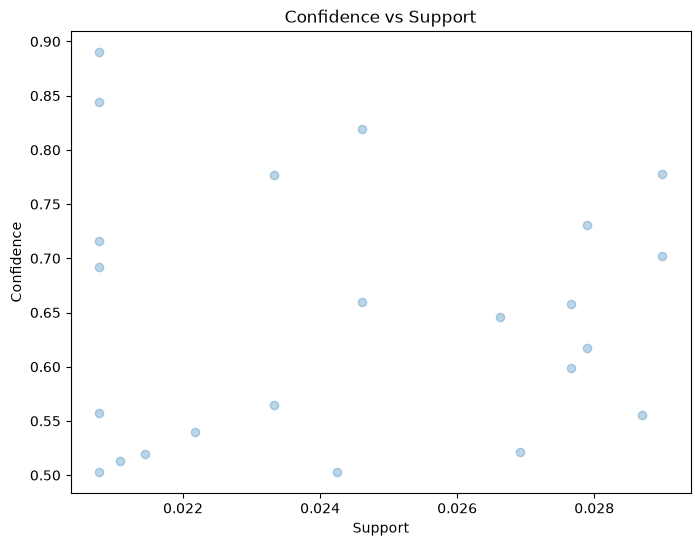

In [11]:
# Examine the relationship between confidence and support
plt.figure(figsize = (8, 6))
plt.scatter(rules["support"], rules["confidence"], alpha = 0.3)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Confidence vs Support")
plt.show()





9. Create a scatter plot with support on the x-axis and lift on the y-axis using the rules data. You should set a value for "alpha" in your scatter plot to increase the transparency of the data points since there is likely to be some overlap.

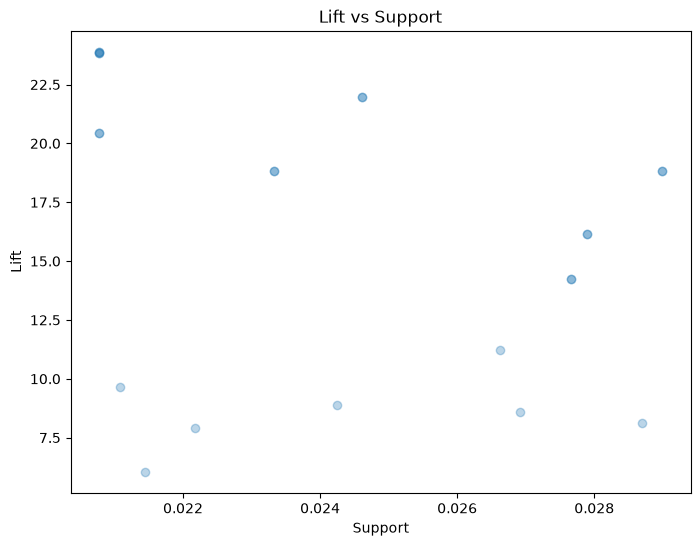

In [12]:
# Examine the relationship between lift and support
plt.figure(figsize = (8, 6))
plt.scatter(rules["support"], rules["lift"], alpha = 0.3)
plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Lift vs Support")
plt.show()  





10. In the following empty markdown cell, briefly respond to the following questions:
    1. Select one of the rules from the top 10 rules by lift and explain in words what the rule is telling you, i.e., how are the antecedents, consequents, and lift value related?
    2. In what region of your confidence vs support plot would you find strong rules based on these metrics? Are there any rules in this region?
    3. In what region of your lift vs support plot would you find strong rules based on these metrics? Are there any rules in this region?

1. The rule {GREEN REGENCY TEACUP AND SAUCER} → {PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER} has support 0.021, confidence 0.557, and lift 23.88. The antecedent is the green teacup and the consequent is the pink and roses teacups together. The support means about 2.1% of all transactions contain all three items. The confidence means that when a customer buys the green teacup, there is about a 56% chance they also buy both the pink and roses versions in the same order. The lift of 23.88 means customers who buy the green teacup are almost 24 times more likely to buy the pink and roses teacups together than customers in general. This is a very strong positive association, which makes sense because these are matching pieces from the same product line that are likely bought as a set.

2. Strong rules on the confidence vs support plot sit in the top right, where both confidence and support are high. Because I used a minimum support of 0.02, all of my rules fall in a narrow support range (about 0.021 to 0.029), so "high support" is relative here. My highest-confidence rules (0.89 and 0.84) are three-item regency teacup rules, and they sit on the left at the lowest support of 0.021. The rules closest to the top-right region are {PINK REGENCY} → {GREEN REGENCY} (support 0.025, confidence 0.82) and {GREEN REGENCY} → {ROSES REGENCY} (support 0.029, confidence 0.78). So there are a few rules near this region, but no rule combines the very highest confidence with the highest support.

3. Strong rules on the lift vs support plot sit in the top right, where both lift and support are high, although lift can still be meaningful at low support. My highest-lift rules (about 23.9) are the three-item regency teacup rules, and they sit on the left at the lowest support of 0.021. The rules {ROSES REGENCY} ↔ {GREEN REGENCY} have the highest support (0.029) while still having a very high lift (18.83), so they are the closest to the strong-rule region and are strong on both measures. All of my rules have a lift well above 1, so every rule represents a positive association.